# Ensembles
<h3> План семинара </h3>

* **Bagging**
 - Bootstrap
 - Как построить доверительный интревал с помощью bootstrap
 - Описание композиции Bagging
 - Bagging в применении в DT

* **Bias-vairance trade-off**
  - Разложение ошибки на Bias и Variance
  - bias\variance для bagging и boosting
    
* **Random Forest**
 - Алгоритм построения случайного леса
 - Применение RandomForest на реальной задаче (предсказание оттока клиентов)
 - Out-of-bag error

* **Основные выводы**

In [ ]:
#@title import
from IPython.display import Image

import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10, 6
import seaborn as sns
%matplotlib inline

from sklearn.datasets import load_digits as load
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score

----------
<h1 align="center">Bagging</h1>

**Вопросы для самоконтроля**
* Зачем нужно строить композиции над алгоритмами?
* Что такое bootstrap-выборка?
* Что такие RSM, Pasting?
* Какие бывают варианты построения композиций N базовых алгоритмов классификации?
* Что такое Bagging?
* Почему работает Bagging?

### Bootstrap

<img src='https://github.com/girafe-ai/ml-course/blob/22f_basic/week0_05_trees_and_ensembles/img/bootstrap.png?raw=1'>

** Важно! **
    - Бутстрепная выборка имеет такой же размер, что и исходная
    - Генерация с повторениями

### Bagging

## $$a_{Bagging}(x) = \frac{1}{M}\sum_{i=1}^M a_i(x)$$

$a_i(x)$ - обучен на бутстреп-выборке $X^i$

<img src='https://github.com/girafe-ai/ml-course/blob/22f_basic/week0_05_trees_and_ensembles/img/bagging.png?raw=1'>

## Bagging в действии

Импортируем датасет `load_digits` из `sklearn.datasets`, который содержит изображения рукописных цифр (от 0 до 9).

Описание:

* **Назначение:** Задача классификации рукописных цифр.
* **Размер:** 1797 изображений.
* **Формат изображений:** 8×8 пикселей (в градациях серого).
* **Особенности данных:**

  * Каждое изображение представлено как массив из 64 чисел (8×8).
  * Значения пикселей варьируются от 0 до 16 (градации яркости).
* **Целевые метки (`target`):** Цифры от 0 до 9.
* **Применение:** Используется для обучения и тестирования алгоритмов классификации.


Этот датасет очень популярен для отработки задачи многоклассовой Классификации и тестирования алгоритмов.

In [ ]:
digits = load()
X = digits.data
y = digits.target

f = X.shape[1]

plt.imshow(X[10].reshape(8, 8))
plt.title('One of the samles')
print(f'Unic values of target: {np.unique(y)}\n')

Мы импортируем два варианта решающего дерева — классическое и с рандомизацией выбора признаков — чтобы сравнить поведение базовой модели с более "шумной" версией в контексте бэггинга. Это позволяет наглядно показать, как рандомизация может повысить устойчивость ансамбля и снизить переобучение.


In [ ]:
dt_alg = DecisionTreeClassifier(max_features='sqrt') # Решающее дерево с рандомизацией в сплитах
dt_rand_feat_alg = DecisionTreeClassifier() # Обычное решающее дерево

Качество классификации одним решающим деревом:

In [ ]:
print("Decision tree:", cross_val_score(dt_alg, X, y, scoring='accuracy', cv=5).mean())

Качество бэггинга над решающими деревьями:

In [ ]:
print("Bagging:", cross_val_score(BaggingClassifier(dt_alg, n_estimators=10), X, y, scoring='accuracy', cv=5).mean())

- Какой недостаток есть у деревьев?
- Как bagging борется с этим недостатком?

- Как можно улучшить качество? При построении каждого узла отбирать случайные max_features признаков и искать информативное разбиение только по одному из них.

In [ ]:
print("Randomized Bagging:", cross_val_score(BaggingClassifier(dt_rand_feat_alg), X, y, scoring='accuracy', cv=5).mean())

In [ ]:
#@title Попробуйте проинтерпретировать результат сами а потом прочитайте текст запустив код)))
from IPython.display import display, HTML

html_content = """
<div style="background-color: white; color: black; font-family: sans-serif; padding: 15px; border: 1px solid #ccc; border-radius: 8px;">

<h2>Интерпретация и выводы:</h2>

<hr>

<p><strong>— Почему Bagging показал лучше?</strong><br>
Без дополнительной рандомизации деревья могут находить более информативные разбиения, а бэггинг уже сам по себе хорошо борется с переобучением.</p>

<p><strong>— Почему <code>max_features='sqrt'</code> (рандомизация признаков) ухудшила результат?</strong><br>
Такой подход полезен при большом числе признаков или сильной корреляции между ними.<br>
В данном случае (например, с датасетом цифр) — возможно, признаки и так хорошо работают совместно, и ограничение <code>sqrt</code> снижает эффективность сплитов.</p>

<hr>

<p><strong>— Вывод:</strong><br>
Рандомизация признаков (<code>max_features='sqrt'</code>) — имеет место быть, но не всегда улучшает результат.<br>
Её эффективность зависит от природы данных. В задачах с умеренным числом признаков и их хорошей информативностью, обычный бэггинг может работать лучше.<br><br>
Надо помнить, что при бэггинге не так уж и плохо, что каждый отдельный алгоритм переобучается!<br>
Каждый алгоритм должен быть наиболее "специфичным", чтобы сфокусироваться на определённых аспектах в данных.</p>

</div>
"""

display(HTML(html_content))


# Random Forest

<img src='https://github.com/girafe-ai/ml-course/blob/22f_basic/week0_05_trees_and_ensembles/img/forest.jpeg?raw=1' width=700>

##### Алгоритм построения случайного леса из $N$ деревьев

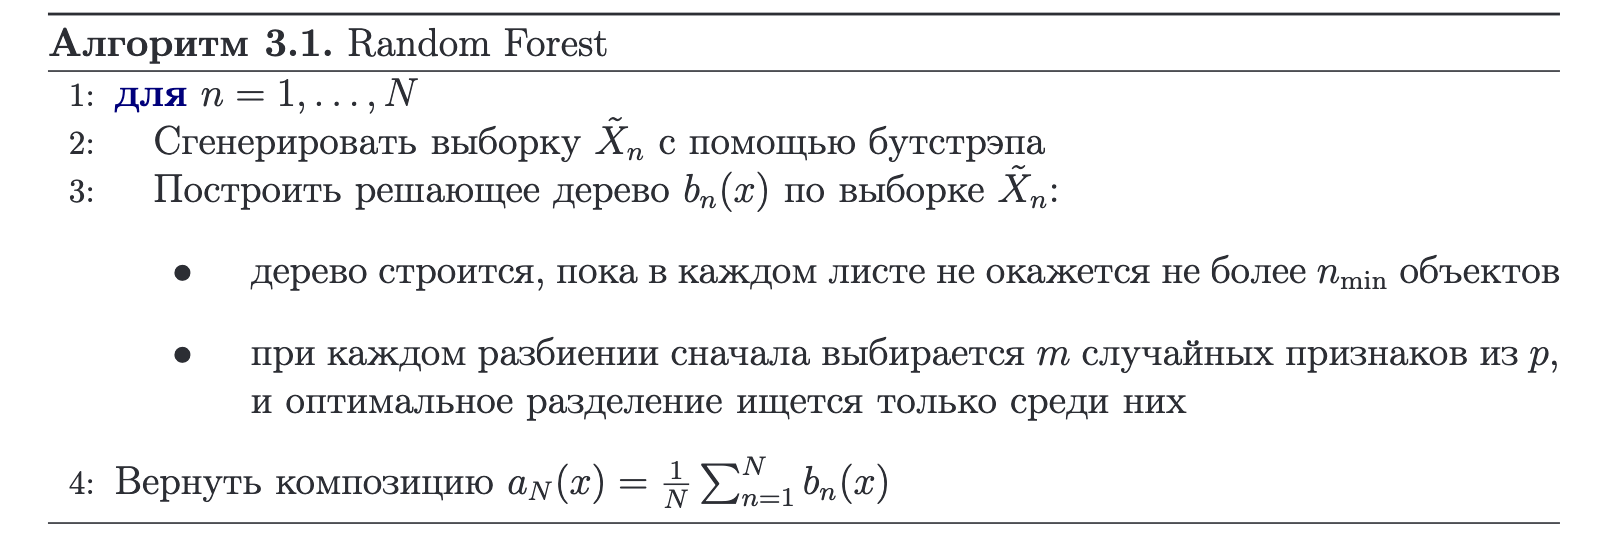

Итоговый классификатор:

$$ a(x) = \dfrac{1}{N} \sum_{i=1}^{N} b_i(x)$$

$m$ советуют выбирать равным:
- $\sqrt{n}$ для классификации
- $\dfrac{n}{3}$ для регрессии

In [ ]:
# @title Random Forest by hand
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.metrics import mean_squared_error

X = np.linspace(-2*np.pi, 2*np.pi, 100)
y = np.cos(X)*2 + np.random.randn(100)*.7 + 2
XX = X.reshape((-1, 1))
def select_(X, y, size:int, slider_sampl_size)->tuple:
  replace = slider_sampl_size==1
  ind = np.random.choice(np.arange(X.shape[0]), size, replace=replace)
  return X[ind].reshape((-1, 1)), y[ind], np.unique(ind).shape[0] / X.shape[0]

slider_estimatirs = widgets.IntSlider(
    value= 1,
    min= 1,
    max= 70,
    step=1,
    description='Num estimators'
)

slider_sampl_size = widgets.FloatSlider(
    value= 1.0,
    min= .01,
    max= 1,
    step=.01,
    description='Volume of Sampl'
)

slider_msl = widgets.IntSlider(
    value= 1,
    min= 1,
    max= 20,
    step=1,
    description='MinSamplesLeaf'
)

def update_plot(slider_estimatirs, slider_sampl_size, slider_msl):
  slider_estimatirs = int(slider_estimatirs)
  slider_sampl_size = float(slider_sampl_size)
  slider_msl = int(slider_msl)
  fig, ax = plt.subplots(1, 2, figsize=(13, 6))
  ax[0].scatter(X, y, color='black', s=40)
  y_pred_matr = []
  prop_list = []

  for _ in range(slider_estimatirs):
    xx, yy, prop = select_(X, y, int(X.shape[0]*slider_sampl_size), slider_sampl_size)
    dtr = tree.DecisionTreeRegressor(min_samples_leaf=slider_msl)
    dtr.fit(xx, yy)
    y_pred = dtr.predict(XX)
    y_pred_matr.append(y_pred)
    prop_list.append(prop)
    ax[0].plot(X, y_pred, color='green', alpha=.3, label=f'$y=a_i(x)$')

  mean_pred = np.array(y_pred_matr).mean(axis=0)
  mean_prop = np.array(prop_list).mean().round(2)
  mse = mean_squared_error(y, mean_pred)
  ax[1].scatter(X, y, color='black', s=30)
  ax[1].plot(X, mean_pred, color='red', linewidth=3, label=f'Усредненное предсказание {slider_estimatirs} алгоритмов.')
  ax[0].set_xlabel('X')
  ax[0].set_ylabel('y')
  ax[1].set_xlabel('X')
  ax[1].set_ylabel('y')
  handles, labels = ax[0].get_legend_handles_labels()
  by_label = dict(zip(labels, handles))
  ax[0].legend(by_label.values(), by_label.keys())
  ax[1].legend()
  ax[0].set_ylim(-1.5, 6.5)
  ax[1].set_ylim(-1.5, 6.5)
  ax[0].grid()
  ax[1].grid()
  if slider_sampl_size == 1:
    info = f'Ансамбль решающих деревьев. MSE: {round(mse, 2)}\nBootstrap-выборка {mean_prop*100} %.\nMinSamplesLeaf: {slider_msl}.'
    plt.suptitle(info)
  else:
    info = f'Ансамбль решающих деревьев. MSE: {round(mse, 2)}\nОбъем выборки {slider_sampl_size*100} %.\nMinSamplesLeaf: {slider_msl}.'
    plt.suptitle(info)


  plt.show()

out = widgets.Output()

def on_slider_change(change):
    A_value = slider_estimatirs.value
    B_value = slider_sampl_size.value
    C_value = slider_msl.value

    with out:
        clear_output(wait=True)
        update_plot(A_value, B_value, C_value)

slider_estimatirs.observe(on_slider_change, 'value')
slider_sampl_size.observe(on_slider_change, 'value')
slider_msl.observe(on_slider_change, 'value')

display(widgets.VBox([slider_estimatirs, slider_sampl_size, slider_msl]))
display(out)

## Random Forest из sklearn

[RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

[RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)


При построениии модели в первую очередь стоит обратить внимание на следующие параметры:

- n_estimators — число деревьев в "лесу"
- criterion — критерий для разбиения выборки в вершине
- max_features — число признаков, по которым ищется разбиение
- min_samples_leaf — минимальное число объектов в листе
- max_depth — максимальная глубина дерева


# Применение RandomForest на реальной задаче (предсказание оттока клиентов)

Данные можно взять тут: https://github.com/Yorko/mlcourse_open/blob/master/data/telecom_churn.csv


### 📄 **Описание датасета: Telecom Churn**

Этот датасет содержит информацию о клиентах телеком-компании и используется для решения задачи **предсказания оттока клиентов** (*churn prediction*).

---

### 🧩 **Цель:**

Предсказать, уйдёт ли клиент от оператора (отток = 1) или останется (отток = 0), на основе его активности и характеристик.

---

### 🔢 **Основные характеристики:**

* **Число наблюдений:** \~3 000 клиентов
* **Целевая переменная:** `Churn` (булевская метка: `True` — клиент ушёл, `False` — остался)

---

### 🔠 **Категориальные признаки:**

* `State` — штат проживания клиента
* `International plan` — международный тарифный план (Yes/No)
* `Voice mail plan` — наличие голосовой почты (Yes/No)

---

### 🔢 **Числовые признаки:**

* `Account length` — как долго клиент пользуется услугами (в днях)
* `Number vmail messages` — число голосовых сообщений
* `Total day minutes / calls / charge` — активность днём
* `Total evening minutes / calls / charge` — активность вечером
* `Total night minutes / calls / charge` — активность ночью
* `Total intl minutes / calls / charge` — международные звонки
* `Customer service calls` — число звонков в поддержку




In [ ]:
!wget https://raw.githubusercontent.com/Yorko/mlcourse.ai/master/data/telecom_churn.csv

In [ ]:
df = pd.read_csv("telecom_churn.csv")

cols = []
for i in df.columns:
    if (df[i].dtype == "float64") or (df[i].dtype == 'int64'):
        cols.append(i)

X, y = df[cols].copy(), np.asarray(df["Churn"],dtype='int8')

Запустим алноритм "из коробки"

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfc = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)

results = cross_val_score(rfc, X, y, cv=skf, scoring='accuracy')
print("CV accuracy score: {:.2f}%".format(results.mean()*100))

`oob_score`--?

Об этой метрике мы поговорим позже)

Улучшим этот результат: посмотрим, как ведут себя кривые валидации при изменении основных параметров

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
trees_grid = [5, 10, 15, 20, 30, 50, 75, 100, 500]

for ntrees in trees_grid:
    rfc = RandomForestClassifier(n_estimators=ntrees, random_state=42, n_jobs=-1, oob_score=True)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} trees".format(max(test_acc.mean(axis=1))*100,
                                                        trees_grid[np.argmax(test_acc.mean(axis=1))]))

In [ ]:
plt.style.use('ggplot')
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trees_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(trees_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(trees_grid, test_acc.mean(axis=1) - test_acc.std(axis=1), test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(trees_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1), test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("N_estimators")

Подбираем параметр max_depth:

In [ ]:
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
max_depth_grid = [3, 5, 7, 9, 11, 13, 15, 17, 20, 22, 24]

for max_depth in max_depth_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True, max_depth=max_depth)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} max_depth".format(max(test_acc.mean(axis=1))*100,
                                                        max_depth_grid[np.argmax(test_acc.mean(axis=1))]))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_depth_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(max_depth_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(max_depth_grid, test_acc.mean(axis=1) - test_acc.std(axis=1), test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(max_depth_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1), test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Max_depth")

Параметр min_samples_leaf также выполняет функцию регуляризатора.

In [ ]:
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
min_samples_leaf_grid = [1, 3, 5, 7, 9, 11, 13, 15, 17, 20, 22, 24]

for min_samples_leaf in min_samples_leaf_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                 oob_score=True, min_samples_leaf=min_samples_leaf)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} min_samples_leaf".format(max(test_acc.mean(axis=1))*100,
                                                        min_samples_leaf_grid[np.argmax(test_acc.mean(axis=1))]))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(min_samples_leaf_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(min_samples_leaf_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(min_samples_leaf_grid, test_acc.mean(axis=1) - test_acc.std(axis=1), test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(min_samples_leaf_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1), test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Min_samples_leaf")

Рассмотрим такой параметр как max_features. Для задач классификации по умолчанию используется $\sqrt{n}$, где $n$ — число признаков.

In [ ]:
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
max_features_grid = [2, 4, 6, 8, 10, 12, 14, 16]

for max_features in max_features_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                 oob_score=True, max_features=max_features)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best accuracy on CV is {:.2f}% with {} max_features".format(max(test_acc.mean(axis=1))*100,
                                                        max_features_grid[np.argmax(test_acc.mean(axis=1))]))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_features_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(max_features_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(max_features_grid, test_acc.mean(axis=1) - test_acc.std(axis=1), test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(max_features_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1), test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Max_features")

В нашем случае оптимальное число признаков - 4.

Итак, итоговый перебор параметров будет выглядеть следующим образом:

In [ ]:
parameters = {'max_features': [4, 7, 10, 13],
              'min_samples_leaf': [1, 3, 5, 7],
              'max_depth': [5,10,15,20]}

rfc = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, oob_score=True)
gcv = GridSearchCV(rfc, parameters, n_jobs=-1, cv=skf, verbose=1)
gcv.fit(X, y)

### Есть ли переобучение с увеличением числа деревьев?

In [ ]:
%%time

for n_estimators in [10, 40, 100, 200, 600, 1000]:
    clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=n_estimators, n_jobs=4)
    clf = clf.fit(X_train, y_train)
    train_acc, test_acc = accuracy_score(clf.predict(X_train), y_train), accuracy_score(clf.predict(X_test), y_test)
    print('n_estimators = %4s train_acc = %4s test_acc = %4s' %(n_estimators, train_acc, test_acc))

In [ ]:
%%time

for n_estimators in [10, 40, 100, 200, 600, 1000]:
    clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=7), n_estimators=n_estimators, n_jobs=4)
    clf = clf.fit(X_train, y_train)
    train_acc, test_acc = accuracy_score(clf.predict(X_train), y_train), accuracy_score(clf.predict(X_test), y_test)
    print('n_estimators = %4s train_acc = %4s test_acc = %4s' %(n_estimators, train_acc, test_acc))

In [ ]:
%%time

for n_estimators in [10, 40, 100, 200, 600, 1000]:
    clf = BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=14), n_estimators=n_estimators, n_jobs=4)
    clf = clf.fit(X_train, y_train)
    train_acc, test_acc = accuracy_score(clf.predict(X_train), y_train), accuracy_score(clf.predict(X_test), y_test)
    print('n_estimators = %4s train_acc = %4s test_acc = %4s' %(n_estimators, train_acc, test_acc))

Вывод??

Ансамбль типа `Bagging` очень сложно переобучить!)

### Out-of-bag error

<img src='https://github.com/girafe-ai/ml-course/blob/22f_basic/week0_05_trees_and_ensembles/img/oob.png?raw=1' width=700>

**Задача** Покажите, что примерно 37% примеров остаются вне выборки бутстрэпа и не используются при построении k-го дерева.

**Решение** Пусть в выборке $l$ объектов. На каждом шаге все объекты попадают в подвыборку с возвращением равновероятно, т.е отдельный объект — с вероятностью $\dfrac{1}{l}$. Вероятность того, что объект НЕ попадет в подвыборку (т.е. его не взяли $l$ раз): $(1-\dfrac{1}{l})^l$


$$\lim_{l \rightarrow +\infty} (1-\dfrac{1}{l})^l = \dfrac{1}{e}$$

Тогда вероятность попадания конкретного объекта в подвыборку $1 - \dfrac{1}{e} \approx 63\%$.

Out-of-Bag оценка — это усредненная оценка базовых алгоритмов на тех ~37% данных, на которых они не обучались.

### Как вычисляется feature importance?

Каждый узел дерева использует конкретную фичу для максимизации критерия информативности. Для каждой фичи можно посчитать взвешенное (по размеру выборки) суммарное (по всем вершинам) изменение критерия информативности.
И с помощью полученных результатов отсортировать фичи по важности.
Для леса, данные значения можно вначале усреднить по всем деревьям, а уже затем отсортировать.

Также можно напрямую измерять влияние фичи на качество модели. Например случайно переставлять значения какой-то фичи в тестовой выборке и смотреть как сильно ухудшается качество.

In [ ]:
forest = RandomForestRegressor(n_estimators=1000, max_features=10,
                                random_state=0)

forest.fit(X, y)
importances = forest.feature_importances_

In [ ]:
sns.barplot(pd.Series(importances, index=X.columns).sort_values(), color='grey', edgecolor='black', orient='h')

<h1 align="center">Выводы</h1>

**Bagging**:
    - Одна из лучших техник для построения алгоритмов ML
    - Линейно уменьшает разброс и не уменьшает смещение (если не коррелированы ответы базовых алоритмов)
    - Слабое переобучение
    - НО переобучение ЕСТЬ -- от сложности одного алгоритма, лучше все же немного обрезать деревья

**Random Forest**

Плюсы:
- имеет высокую точность предсказания, на большинстве задач будет лучше линейных алгоритмов; точность сравнима с точностью бустинга
- практически не чувствителен к выбросам в данных из-за случайного сэмлирования
- не чувствителен к масштабированию (и вообще к любым монотонным преобразованиям) значений признаков, связано с выбором случайных подпространств
- не требует тщательной настройки параметров, хорошо работает «из коробки». С помощью «тюнинга» параметров можно достичь прироста от 0.5 до 3% точности в зависимости от задачи и данных
- способен эффективно обрабатывать данные с большим числом признаков и классов
- одинаково хорошо обрабатывет как непрерывные, так и дискретные признаки
- редко переобучается, на практике добавление деревьев почти всегда только улучшает композицию, но на валидации, после достижения определенного количества деревьев, кривая обучения выходит на асимптоту
- для случайного леса существуют методы оценивания значимости отдельных признаков в модели
- хорошо работает с пропущенными данными; сохраняет хорошую точность, если большая часть данных пропущенна
- предполагает возможность сбалансировать вес каждого класса на всей выборке, либо на подвыборке каждого дерева
- вычисляет близость между парами объектов, которые могут использоваться при кластеризации, обнаружении выбросов или (путем масштабирования) дают интересные представления данных
- возможности, описанные выше, могут быть расширены до неразмеченных данных, что приводит к возможности делать кластеризацию и визуализацию данных, обнаруживать выбросы
- высокая параллелизуемость и масштабируемость.

Минусы:
- в отличие от одного дерева, результаты случайного леса сложнее интерпретировать
- нет формальных выводов (p-values), доступных для оценки важности переменных
- алгоритм работает хуже многих линейных методов, когда в выборке очень много разреженных признаков (тексты, Bag of words)
- случайный лес не умеет экстраполировать, в отличие от той же линейной регрессии (но это можно считать и плюсом, так как не будет экстремальных значений в случае попадания выброса)
- алгоритм склонен к переобучению на некоторых задачах, особенно на зашумленных данных
- для данных, включающих категориальные переменные с различным количеством уровней, случайные леса предвзяты в пользу признаков с большим количеством уровней: когда у признака много уровней, дерево будет сильнее подстраиваться именно под эти признаки, так как на них можно получить более высокое значение оптимизируемого функционала (типа прироста информации)
- если данные содержат группы коррелированных признаков, имеющих схожую значимость для меток, то предпочтение отдается небольшим группам перед большими
- больший размер получающихся моделей. Требуется $O(NK)$ памяти для хранения модели, где $K$ — число деревьев.

## Вопросы и Ответы:

**1) Какая должна быть глубина деревьев в случайном лесу?**

Ошибка модели (на которую мы можем повлиять) состоит из смещения и разброса. Разброс мы уменьшаем с помощью процедуры бэггинга. На смещение бэггинг не влияет, а хочется, чтобы у леса оно было небольшим. Поэтому смещение должно быть небольшим у самих деревьев, из которых строится ансамбль.

У неглубоких деревьев малое число параметров, то есть дерево способно запомнить только верхнеуровневые статистики обучающей подвыборки. Они во всех подвыборках будут похожи, но будут не очень подробно описывать целевую зависимость. Поэтому при изменении обучающей подвыборки предсказание на тестовом объекте будет стабильным, но не точным (низкая дисперсия, высокое смещение).

Наоборот, у глубоких деревьев нет проблем запомнить подвыборку подробно. Поэтому предсказание на тестовом объекте будет сильнее меняться в зависимости от обучающей подвыборки, зато в среднем будет близко к истине (высокая дисперсия, низкое смещение).

Вывод: используем глубокие деревья.


**2) Сколько признаков надо подавать дереву для обучения?**
Ограничивая число признаков, которые используются в обучении одного дерева, мы также управляем качеством случайного леса. Чем больше признаков, тем больше корреляция между деревьями и тем меньше чувствуется эффект от ансамблирования. Чем меньше признаков, тем слабее сами деревья.

Практическая рекомендация — брать корень из числа всех признаков для классификации и треть признаков для регрессии.

**3) Сколько должно быть деревьев в случайном лесе?**

Выше было показано, что увеличение числа элементарных алгоритмов в ансамбле не меняет смещения и уменьшает разброс. Так как число признаков и варианты подвыборок, на которых строятся деревья в случайном лесе, ограничены, уменьшать разброс до бесконечности не получится. Поэтому имеет смысл построить график ошибки от числа деревьев и ограничить размер леса в тот момент, когда ошибка перестанет значимо уменьшаться.

Вторым практическим ограничением на количество деревьев может быть время работы ансамбля. Однако есть положительное свойство случайного леса: случайный лес можно строить и применять параллельно, что сокращает время работы, если у нас есть несколько процессоров. Но процессоров, скорее всего, всё же сильно меньше числа деревьев, а сами деревья обычно глубокие. Поэтому на большом числе деревьев Random Forest может работать дольше желаемого и количество деревьев можно сократить, немного пожертвовав качеством.